In [13]:
import numpy as np
import os
import pandas as pd
import xarray as xr
from glob import glob
import matplotlib.pyplot as plt
import itertools as it
from scipy.stats import linregress
from matplotlib.cm import get_cmap
from utils.constants import chamber_levels_complete
import matplotlib.ticker as ticker
import itertools as it

# Custom function to apply the scientific notation formatter
def use_scientific_notation_for_xaxis():
    plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    plt.gca().xaxis.get_major_formatter().set_scientific(True)
    plt.gca().xaxis.get_major_formatter().set_powerlimits((-3, 3))

prefix_list = ['20231113_3', '20240311' , '20240316']
prefix_names = ['Default', '+ Roots uptake', '+ Roots uptake + phenology']
pft_names = ['Spruce', 'Tamarack', 'Shrub']

outdir = os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract')

def fit_line(x, y):
    filt = ~np.isnan(x) & ~np.isnan(y)
    x = x[filt]
    y = y[filt]
    res = linregress(x, y)
    xnew = np.linspace(x.min(), x.max(), 3)
    ynew = res.slope * xnew + res.intercept
    r2 = res.rvalue**2  # coefficient of determination
    return xnew, ynew, res.slope, res.intercept, r2

## Read the data from `extract_ts_genvars.py` and convert to annual

In [14]:
data_collection = {}
for prefix in prefix_list:
    temp_data = pd.read_csv(os.path.join(outdir, prefix, 'analysis_ts.csv'),
                                          header = [0, 1, 2, 3], index_col = 0, parse_dates=True)
    # average hummock and hollow; resample to annual
    temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
        ).apply(lambda df: df.iloc[:,0] * 0.64 + df.iloc[:,1] * 0.36).resample('1Y').mean()
    temp_data.index = temp_data.index.year
    temp_data.columns = temp_data.columns.reorder_levels(['variable', 'pft', 'plot'])
    # focus on ambient plots only
    filt = [chamber_levels_complete[f'{int(c):02d}'][1] == 0 \
            for c in temp_data.columns.get_level_values(2)]
    temp_data = temp_data.loc[:, filt]
    temp_data = temp_data.stack()
    data_collection[prefix] = temp_data

/tmp/ipykernel_1875744/4182852322.py:6: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
/tmp/ipykernel_1875744/4182852322.py:6: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
/tmp/ipykernel_1875744/4182852322.py:6: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1


## Turnover diagnostics

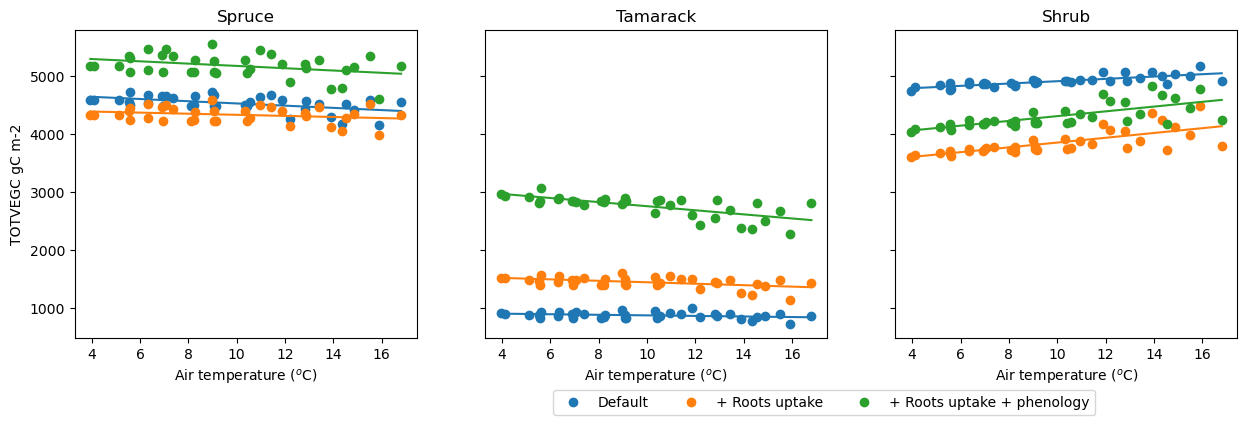

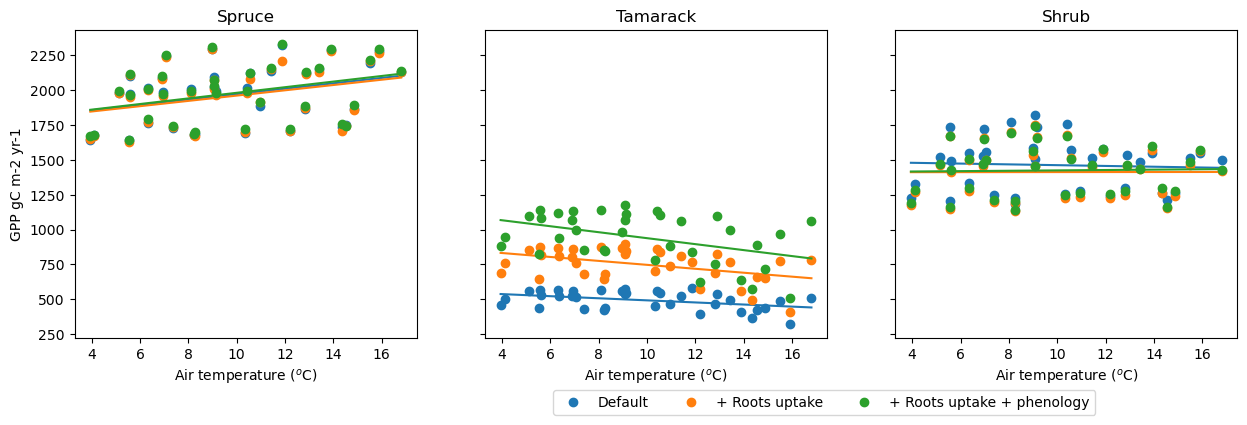

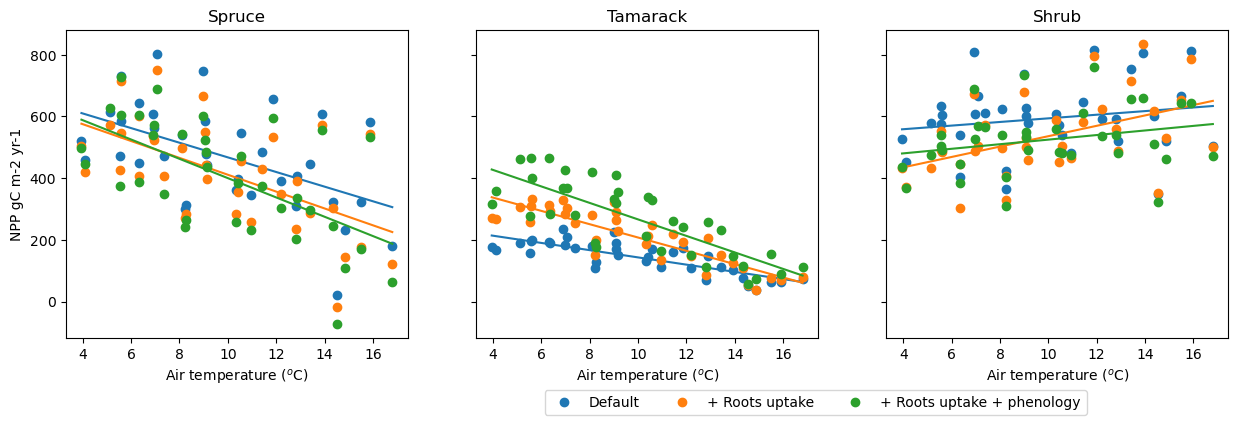

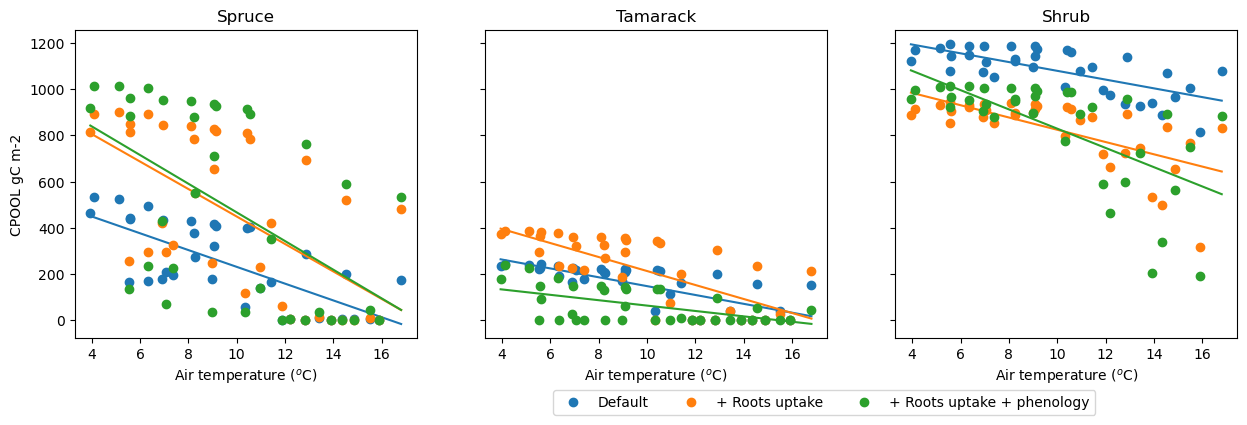

In [11]:
clist = ['#1f77b4', '#ff7f0e', '#2ca02c']

for term, unit in zip(['TOTVEGC', 'GPP', 'NPP', 'CPOOL'],
                      ['gC m-2', 'gC m-2 yr-1', 'gC m-2 yr-1', 'gC m-2']):
    fig, axes = plt.subplots(1, 3, figsize = (15, 4), sharex = True, sharey = True)
    for i, (pft,pftname) in enumerate(zip([2, 3, 11], pft_names)):
        ax = axes.flat[i]
        for j, (prefix, pn) in enumerate(zip(prefix_list, prefix_names)):
            temp_data = data_collection[prefix]
            x = temp_data[('TBOT','0')]
            if term == 'NPP2':
                # this one doesn't include what's sent to storage
                y = temp_data[('AGNPP', str(pft))] + temp_data[('BGNPP', str(pft))].values
            else:
                y = temp_data[(term,str(pft))]
                if not term in ['TOTVEGC','CPOOL']:
                    y = y * 365 * 86400
            ax.plot(x, y, 'o', label = pn)
            xnew, ynew, slope, intercept, r2 = fit_line(x, y)
            ax.plot(xnew, ynew, ls='-', color=clist[j], markerfacecolor='none')
            #ax.text(0.4, 0.65 + j * 0.08, "y$_{MOD,ACO2}$=" + f"{slope:.2f}x+{intercept:.2f}  "
            #        + "R$^2$=" + f"{r2:.3f}",color=clist[j], transform=ax.transAxes)
        ax.set_title(pftname)
        ax.set_xlabel('Air temperature ($^o$C)')
        if i == 0:
            ax.set_ylabel(f'{term} {unit}')
    ax.legend(loc = [-1, -0.25], ncol = 3)

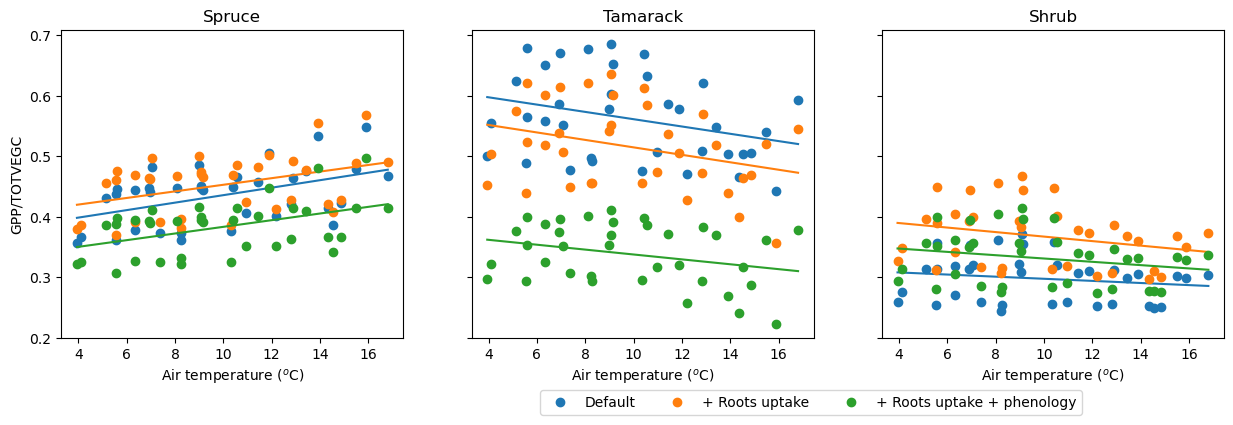

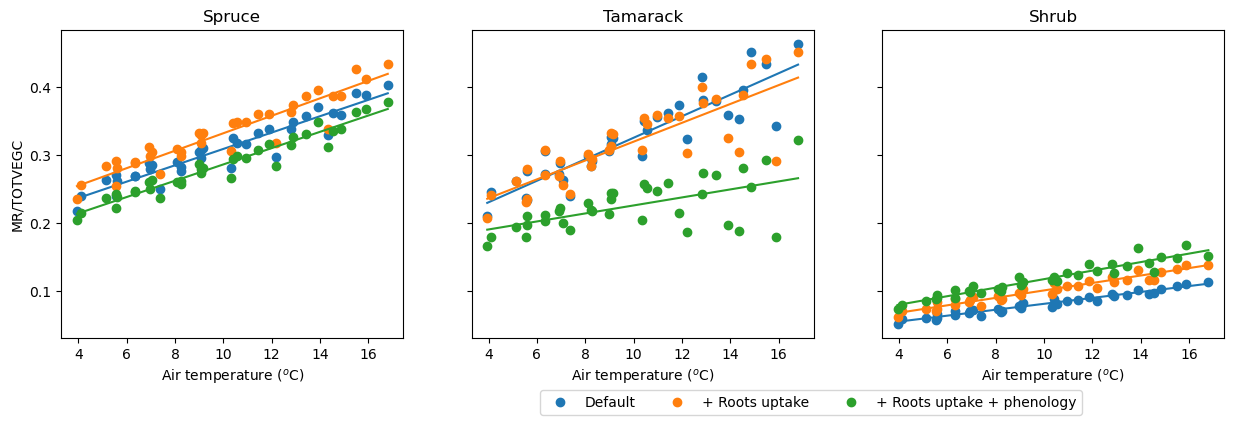

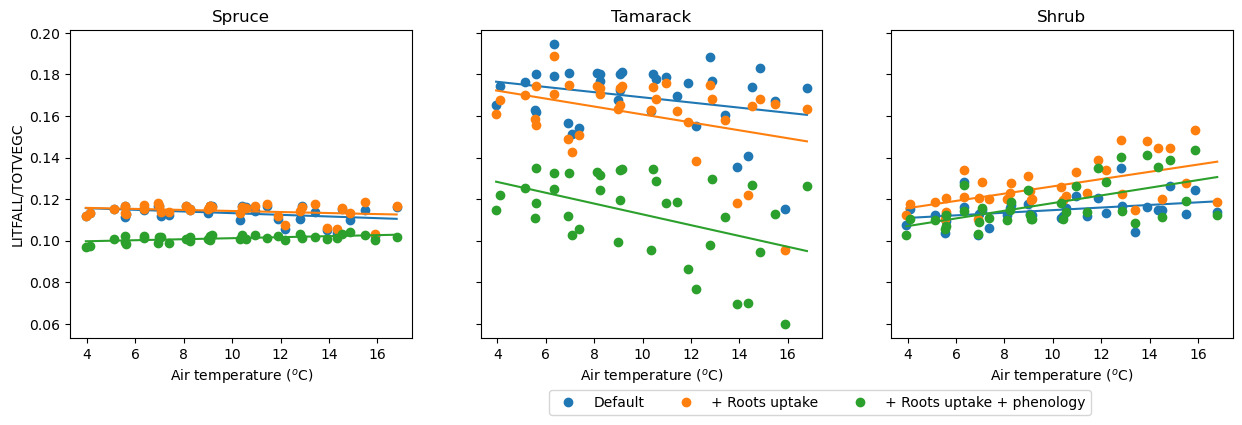

In [7]:
clist = ['#1f77b4', '#ff7f0e', '#2ca02c']

#for term in ['NPP', 'NPP2', 'GPP', 'MR', 'LITFALL', 'LEAFC', 'FROOTC', 'CPOOL']:
for term, unit in zip(['GPP','MR','LITFALL'], ['gC m-2 yr-1','gC m-2 yr-1','gC m-2 yr-1']):
    fig, axes = plt.subplots(1, 3, figsize = (15, 4), sharex = True, sharey = True)
    for i, (pft,pftname) in enumerate(zip([2, 3, 11],pft_names)):
        ax = axes.flat[i]
        for j, (prefix, pn) in enumerate(zip(prefix_list, prefix_names)):
            temp_data = data_collection[prefix]

            if term == 'NPP2':
                # sum up only the field measurable parts, not storage
                turnover = (temp_data[('AGNPP',str(pft))] + temp_data[('BGNPP',str(pft))])
            else:
                turnover = temp_data[(term,str(pft))]
            if not term in ['LEAFC', 'FROOTC', 'CPOOL']:
                turnover = turnover * 365 * 86400
            turnover = turnover / temp_data[('TOTVEGC',str(pft))]
            x = temp_data[('TBOT','0')]
            ax.plot(x, turnover, 'o', label = pn)

            xnew, ynew, slope, intercept, r2 = fit_line(x, turnover)
            ax.plot(xnew, ynew, ls='-', color=clist[j], markerfacecolor='none')
            #ax.text(0.4, 0.65 + j * 0.08, "y$_{MOD,ACO2}$=" + f"{slope:.2f}x+{intercept:.2f}  "
            #        + "R$^2$=" + f"{r2:.3f}",color=clist[j], transform=ax.transAxes)
        ax.set_title(pftname)
        ax.set_xlabel('Air temperature ($^o$C)')
        if i == 0:
            ax.set_ylabel(f'{term}/TOTVEGC')
    ax.legend(loc = [-1, -0.25], ncol = 3)

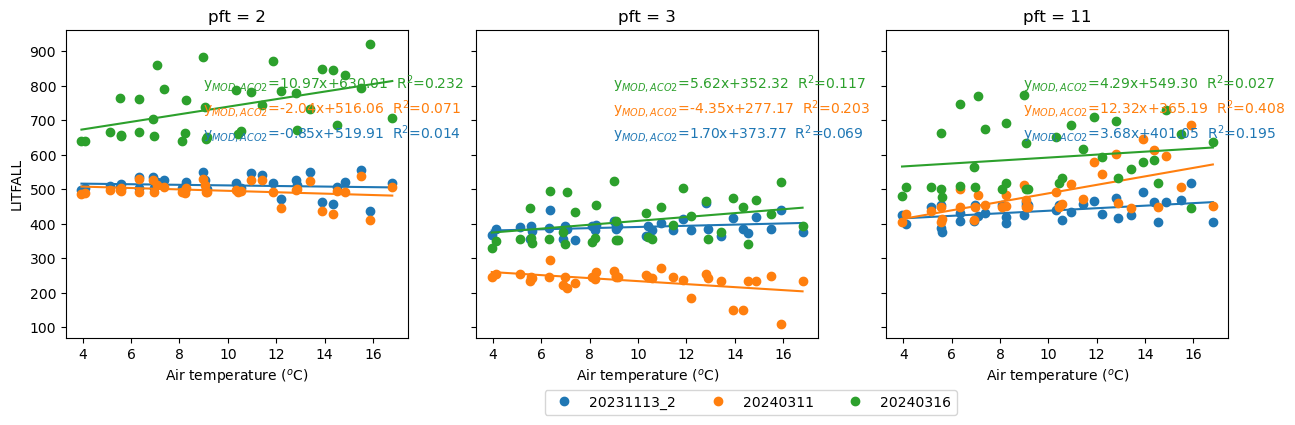

In [4]:
clist = ['#1f77b4', '#ff7f0e', '#2ca02c']

for term in ['LITFALL']:
    fig, axes = plt.subplots(1, 3, figsize = (15, 4), sharex = True, sharey = True)
    for i, pft in enumerate([2, 3, 11]):
        ax = axes.flat[i]
        for j, prefix in enumerate(prefix_list):
            temp_data = data_collection[prefix]

            if term == 'NPP2':
                # sum up only the field measurable parts, not storage
                turnover = (temp_data[('AGNPP',str(pft))] + temp_data[('BGNPP',str(pft))])
            else:
                turnover = temp_data[(term,str(pft))]
            if not term in ['LEAFC', 'FROOTC', 'CPOOL']:
                turnover = turnover * 365 * 86400
            turnover = turnover
            x = temp_data[('TBOT','0')]
            ax.plot(x, turnover, 'o', label = prefix)

            xnew, ynew, slope, intercept, r2 = fit_line(x, turnover)
            ax.plot(xnew, ynew, ls='-', color=clist[j], markerfacecolor='none')
            ax.text(0.4, 0.65 + j * 0.08, "y$_{MOD,ACO2}$=" + f"{slope:.2f}x+{intercept:.2f}  "
                    + "R$^2$=" + f"{r2:.3f}",color=clist[j], transform=ax.transAxes)
        ax.set_title(f'pft = {pft}')
        ax.set_xlabel('Air temperature ($^o$C)')
        if i == 0:
            ax.set_ylabel(f'{term}')
    ax.legend(loc = [-1, -0.25], ncol = 3)

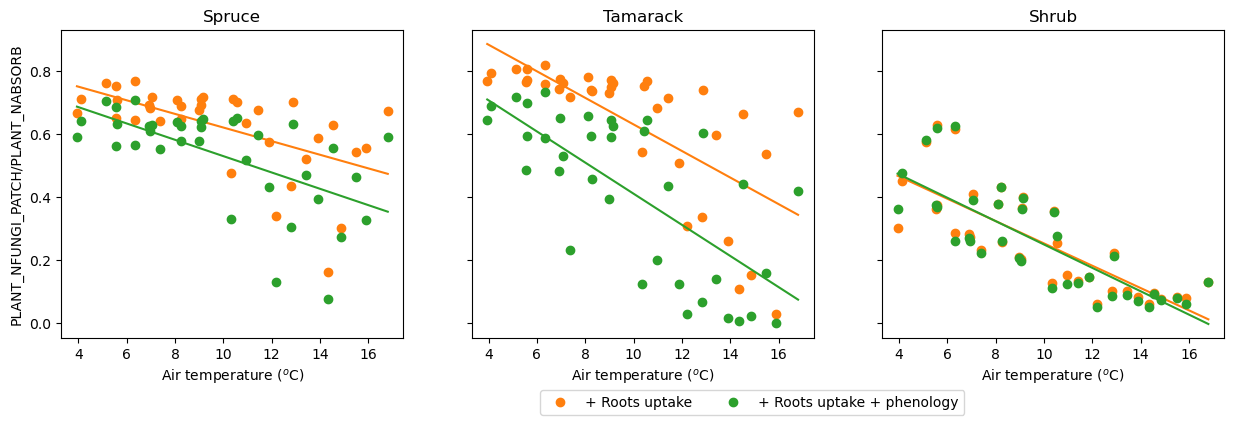

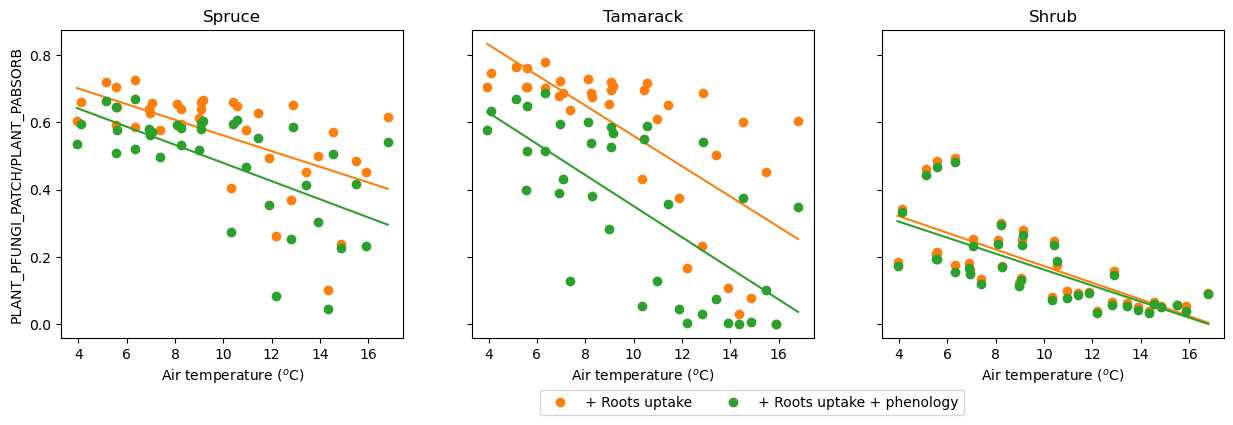

In [25]:
clist = ['#ff7f0e', '#2ca02c'] # #1f77b4', 

for term1, term2 in zip(['PLANT_NABSORB','PLANT_PABSORB'],
                        ['PLANT_NFUNGI_PATCH','PLANT_PFUNGI_PATCH']):
    fig, axes = plt.subplots(1, 3, figsize = (15, 4), sharex = True, sharey = True)
    for i, (pft,pftname) in enumerate(zip([2, 3, 11],pft_names)):
        ax = axes.flat[i]
        for j, (prefix,pn) in enumerate(zip(prefix_list[1:], prefix_names[1:])):
            temp_data = data_collection[prefix]

            a = temp_data[(term1,str(pft))]
            b = temp_data[(term2,str(pft))]

            x = temp_data[('TBOT','0')]
            ax.plot(x, b/a, 'o', label = pn, color = clist[j])

            xnew, ynew, slope, intercept, r2 = fit_line(x, b/a)
            ax.plot(xnew, ynew, ls='-', color=clist[j], markerfacecolor='none')
            #ax.text(0.4, 0.65 + j * 0.08, "y$_{MOD,ACO2}$=" + f"{slope:.2f}x+{intercept:.2f}  "
            #        + "R$^2$=" + f"{r2:.3f}",color=clist[j], transform=ax.transAxes)
        ax.set_title(pftname)
        ax.set_xlabel('Air temperature ($^o$C)')
        if i == 0:
            ax.set_ylabel(f'{term2}/{term1}')
    ax.legend(loc = [-1, -0.25], ncol = 3)

In [16]:
prefix

'20231113_3'

In [10]:
temp_data.columns.levels[0]

Index(['ACTUAL_IMMOB', 'ACTUAL_IMMOB_P', 'AGNPP', 'BGNPP', 'CPOOL',
       'CPOOL_TO_DEADCROOTC', 'CPOOL_TO_DEADSTEMC', 'CPOOL_TO_FROOTC',
       'CPOOL_TO_LEAFC', 'CPOOL_TO_LIVECROOTC', 'CPOOL_TO_LIVESTEMC',
       'DEADCROOTC', 'DEADCROOTC_STORAGE', 'DEADCROOTC_XFER',
       'DEADCROOTC_XFER_TO_DEADCROOTC', 'DEADSTEMC', 'DEADSTEMC_STORAGE',
       'DEADSTEMC_XFER', 'DEADSTEMC_XFER_TO_DEADSTEMC', 'FPG', 'FPG_P', 'FPI',
       'FPI_P', 'FROOTC', 'FROOTC_STORAGE', 'FROOTC_TO_LITTER', 'FROOTC_XFER',
       'FROOTC_XFER_TO_FROOTC', 'FROOT_MR', 'GPP', 'GR', 'H2OSOI_30', 'HR',
       'LEAFC', 'LEAFC_STORAGE', 'LEAFC_TO_LITTER', 'LEAFC_XFER',
       'LEAFC_XFER_TO_LEAFC', 'LEAF_MR', 'LITFALL', 'LIVECROOTC',
       'LIVECROOTC_STORAGE', 'LIVECROOTC_XFER',
       'LIVECROOTC_XFER_TO_LIVECROOTC', 'LIVECROOT_MR', 'LIVESTEMC',
       'LIVESTEMC_STORAGE', 'LIVESTEMC_XFER', 'LIVESTEMC_XFER_TO_LIVESTEMC',
       'LIVESTEM_MR', 'MR', 'NEE', 'NPOOL', 'NPP', 'PPOOL', 'SMINN_30',
       'SMINN_TO_NPOOL'

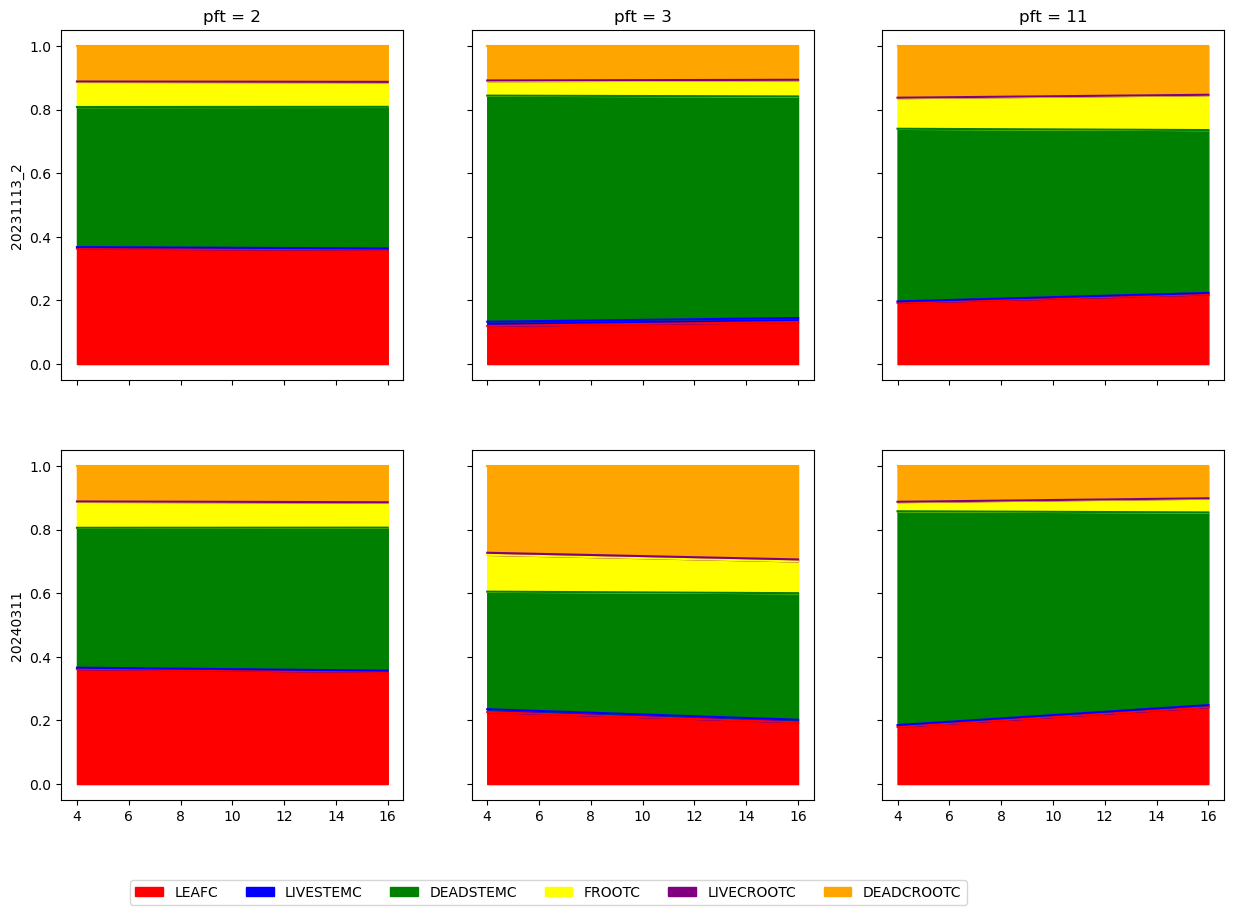

In [3]:
# Only display the fitted line of allometry (standing biomass sizes)
smoothed_size = {}
for prefix,pft in it.product(prefix_list, [2,3,11]):
    smoothed_size[(prefix, pft)] = pd.DataFrame(np.nan, index = [4, 16],
        columns = ['LEAFC', 'LIVESTEMC', 'DEADSTEMC', 'FROOTC', 'LIVECROOTC', 'DEADCROOTC'])
for prefix,pft in it.product(prefix_list, [2,3,11]):
    for term in ['LEAFC', 'LIVESTEMC', 'DEADSTEMC', 'FROOTC', 'LIVECROOTC', 'DEADCROOTC']:
        temp_data = data_collection[prefix]

        organ_size = temp_data[(f'{term}',str(pft))] + \
            temp_data[(f'{term}_STORAGE',str(pft))] + \
            temp_data[(f'{term}_XFER',str(pft))]
        x = temp_data[('TBOT','0')]
        xnew, ynew, slope, intercept, r2 = fit_line(x, organ_size)

        smoothed_size[(prefix, pft)].loc[4, term] = slope * 4 + intercept
        smoothed_size[(prefix, pft)].loc[16, term] = slope * 16 + intercept

    # Convert to fraction of total
    smoothed_size[(prefix, pft)] = smoothed_size[(prefix, pft)] / \
        smoothed_size[(prefix, pft)].sum(axis = 1).values.reshape(-1, 1)

colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange']  # specify your colors
fig, axes = plt.subplots(2, 3, figsize = (15, 10), sharex = True, sharey = True)
for i, pft in enumerate([2, 3, 11]):
    for j,prefix in enumerate(prefix_list):
        ax = axes[j,i]
        df = smoothed_size[(prefix, pft)]
        df.plot(kind='area', stacked=True, color=colors, ax=ax)
        ax.set_ylabel(prefix)
        if j == 0:
            ax.set_title(f'pft = {pft}')
        if (i == 2) and (j == len(prefix_list)-1):
            ax.legend(loc = (-2.2, -0.3), ncol = 6)
        else:
            if ax.legend_:
                ax.legend_.remove()

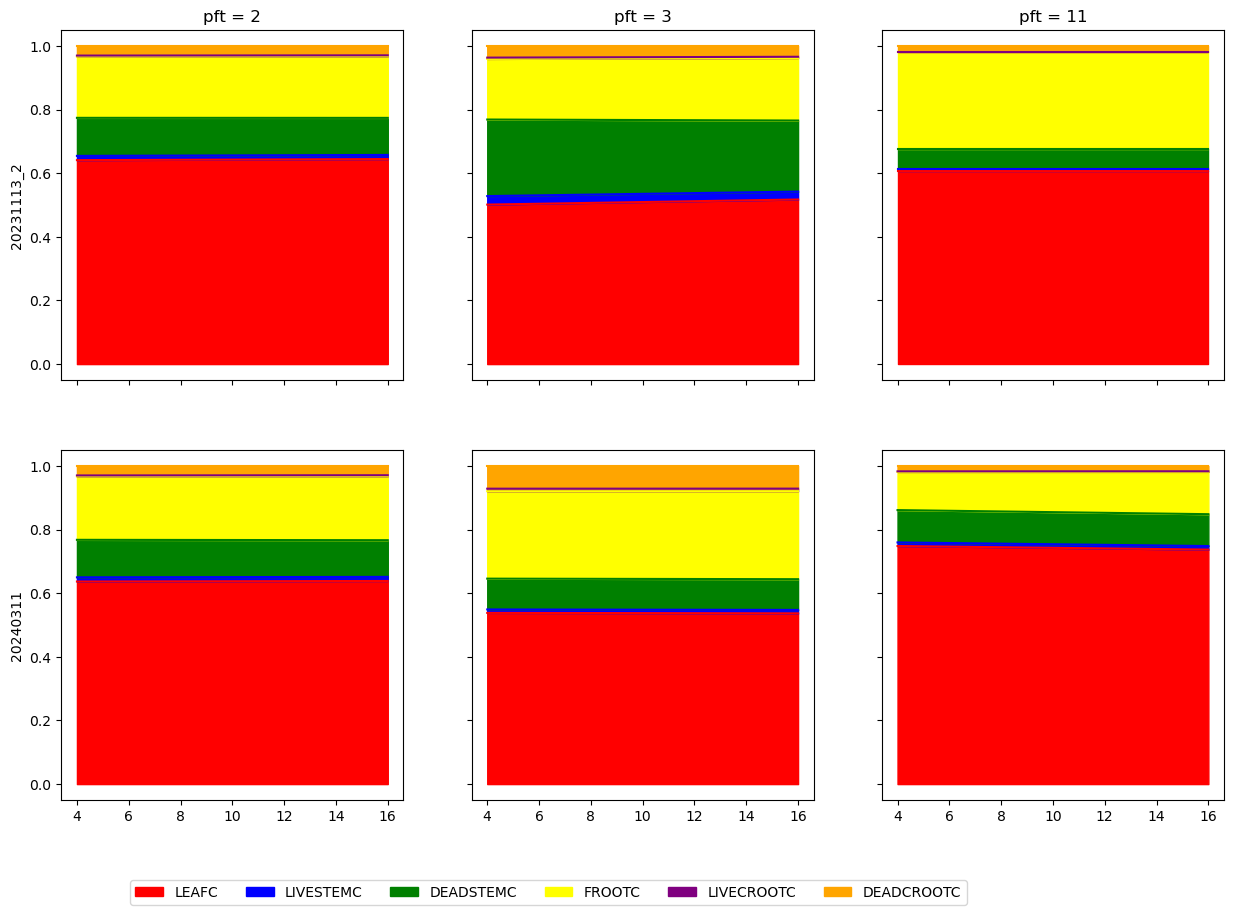

In [25]:
# Only display the fitted line of above-belowground allocation
# (NPP = CPOOL + XFER)
smoothed_size = {}
for prefix,pft in it.product(prefix_list, [2,3,11]):
    smoothed_size[(prefix, pft)] = pd.DataFrame(np.nan, index = [4, 16],
        columns = ['LEAFC', 'LIVESTEMC', 'DEADSTEMC', 'FROOTC', 'LIVECROOTC', 'DEADCROOTC'])
for prefix,pft in it.product(prefix_list, [2,3,11]):
    for term in ['LEAFC', 'LIVESTEMC', 'DEADSTEMC', 'FROOTC', 'LIVECROOTC', 'DEADCROOTC']:
        temp_data = data_collection[prefix]
        organ_size = temp_data[(f'CPOOL_TO_{term}',str(pft))] + \
            temp_data[(f'{term}_XFER_TO_{term}',str(pft))]
        x = temp_data[('TBOT','0')]
        xnew, ynew, slope, intercept, r2 = fit_line(x, organ_size)

        smoothed_size[(prefix, pft)].loc[4, term] = slope * 4 + intercept
        smoothed_size[(prefix, pft)].loc[16, term] = slope * 16 + intercept

    # Convert to fraction of total
    smoothed_size[(prefix, pft)] = smoothed_size[(prefix, pft)] / \
        smoothed_size[(prefix, pft)].sum(axis = 1).values.reshape(-1, 1)

colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange']  # specify your colors
fig, axes = plt.subplots(2, 3, figsize = (15, 10), sharex = True, sharey = True)
for i, pft in enumerate([2, 3, 11]):
    for j,prefix in enumerate(prefix_list):
        ax = axes[j,i]
        df = smoothed_size[(prefix, pft)]
        df.plot(kind='area', stacked=True, color=colors, ax=ax)
        ax.set_ylabel(prefix)
        if j == 0:
            ax.set_title(f'pft = {pft}')
        if (i == 2) and (j == len(prefix_list)-1):
            ax.legend(loc = (-2.2, -0.3), ncol = 6)
        else:
            if ax.legend_:
                ax.legend_.remove()

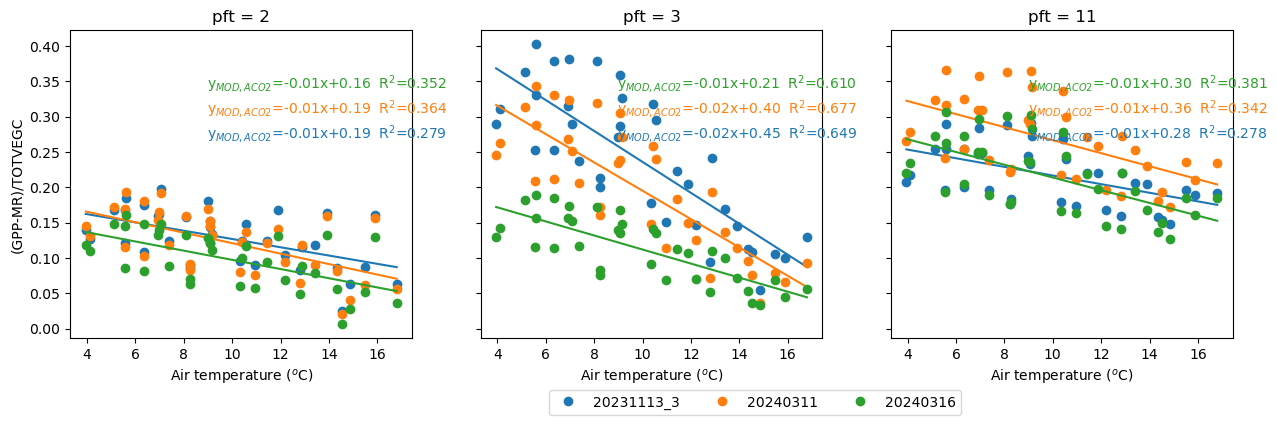

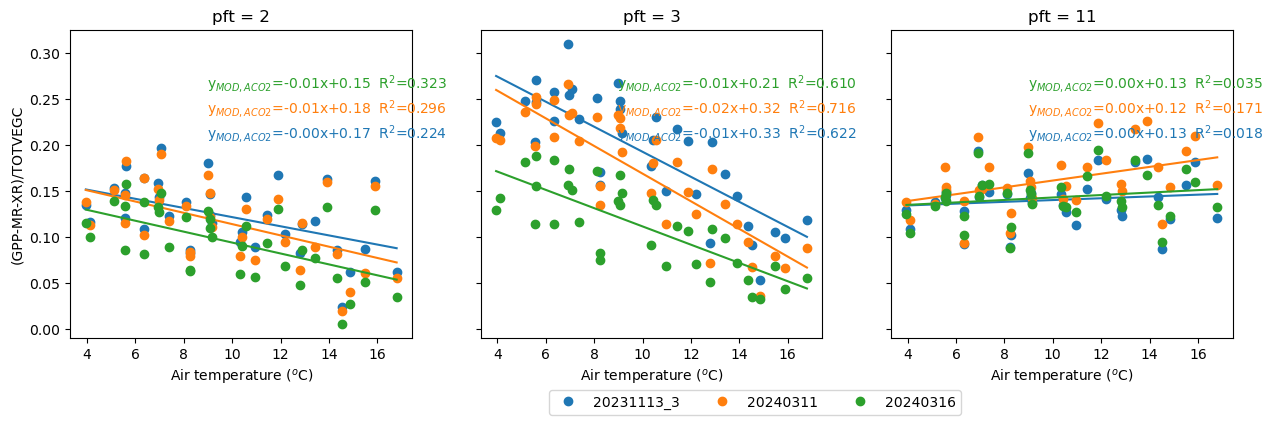

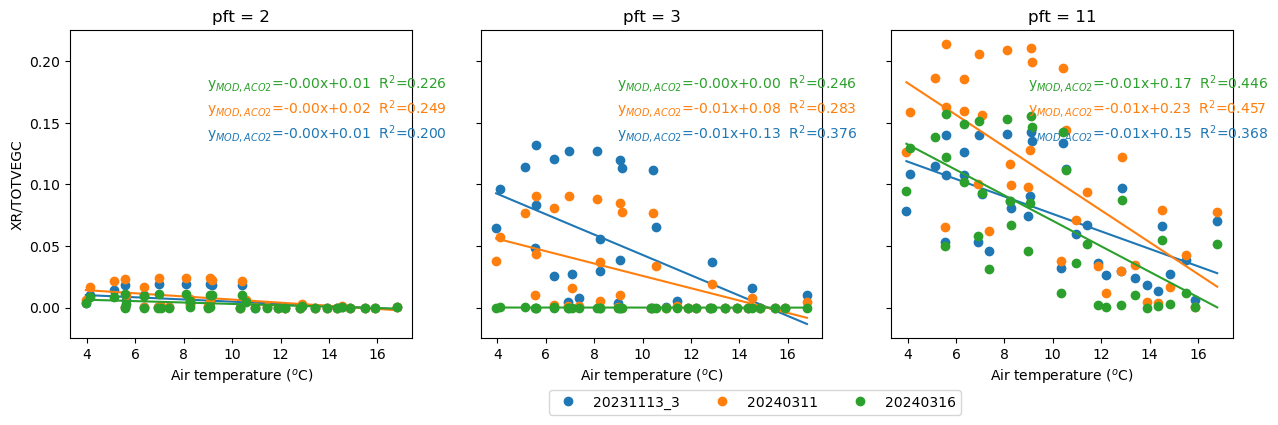

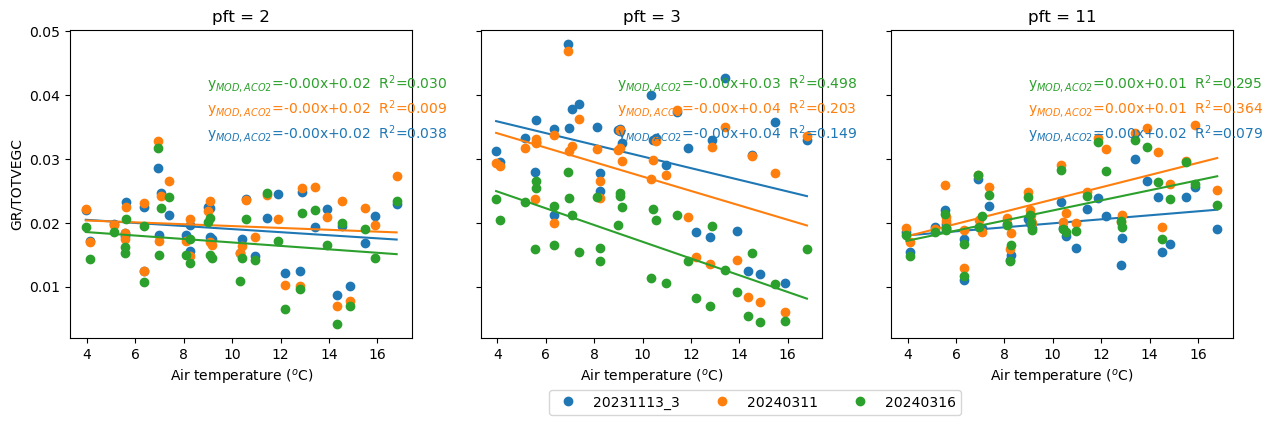

In [8]:
for k in range(4):
    fig, axes = plt.subplots(1, 3, figsize = (15, 4), sharex = True, sharey = True)
    for i, pft in enumerate([2, 3, 11]):
        ax = axes.flat[i]
        for j, prefix in enumerate(prefix_list):
            temp_data = data_collection[prefix][('TOTVEGC', str(pft))]

            if k == 0:
                temp_data2 = data_collection[prefix][('GPP', str(pft))] - \
                            data_collection[prefix][('MR', str(pft))]
            if k == 1:
                temp_data2 = data_collection[prefix][('GPP', str(pft))] - \
                    data_collection[prefix][('MR', str(pft))] - \
                    data_collection[prefix][('XR', str(pft))]
            if k == 2:
                temp_data2 = data_collection[prefix][('XR', str(pft))]
            if k == 3:
                temp_data2 = data_collection[prefix][('GR', str(pft))]

            turnover = temp_data2 * 365 * 86400 / temp_data

            x = data_collection[prefix][('TBOT', '0')]
            ax.plot(x, turnover, 'o', label = prefix)

            xnew, ynew, slope, intercept, r2 = fit_line(x, turnover)
            ax.plot(xnew, ynew, ls='-', color=clist[j], markerfacecolor='none')
            ax.text(0.4, 0.65 + j * 0.08, "y$_{MOD,ACO2}$=" + f"{slope:.2f}x+{intercept:.2f}  "
                    + "R$^2$=" + f"{r2:.3f}",color=clist[j], transform=ax.transAxes)
        ax.set_title(f'pft = {pft}')
        ax.set_xlabel('Air temperature ($^o$C)')
        if i == 0:
            if k == 0:
                ax.set_ylabel(f'(GPP-MR)/TOTVEGC')
            if k == 1:
                ax.set_ylabel(f'(GPP-MR-XR)/TOTVEGC')
            if k == 2:
                ax.set_ylabel('XR/TOTVEGC')
            if k == 3:
                ax.set_ylabel('GR/TOTVEGC')
    ax.legend(loc = [-1, -0.25], ncol = 3)

## Nutrient uptake diagnostics

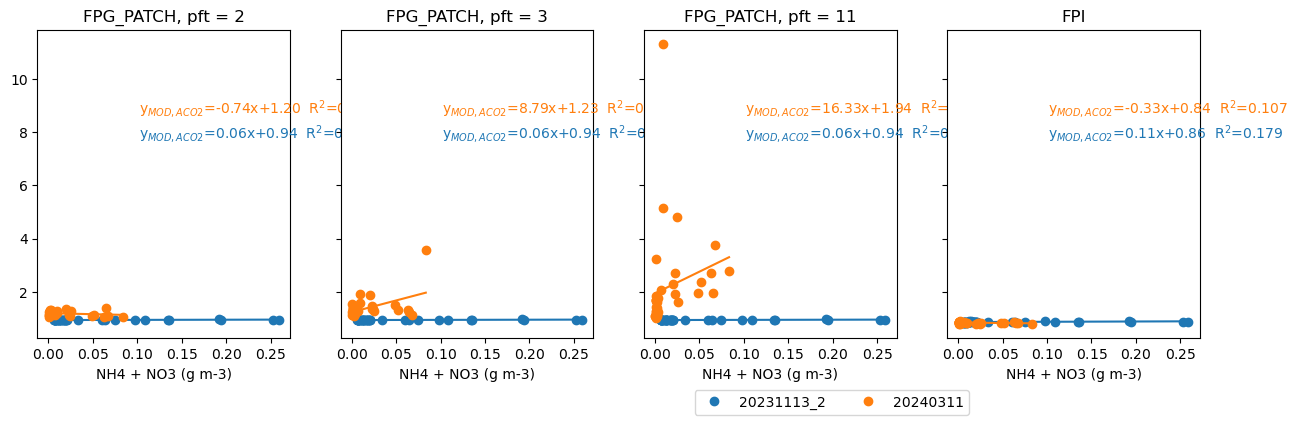

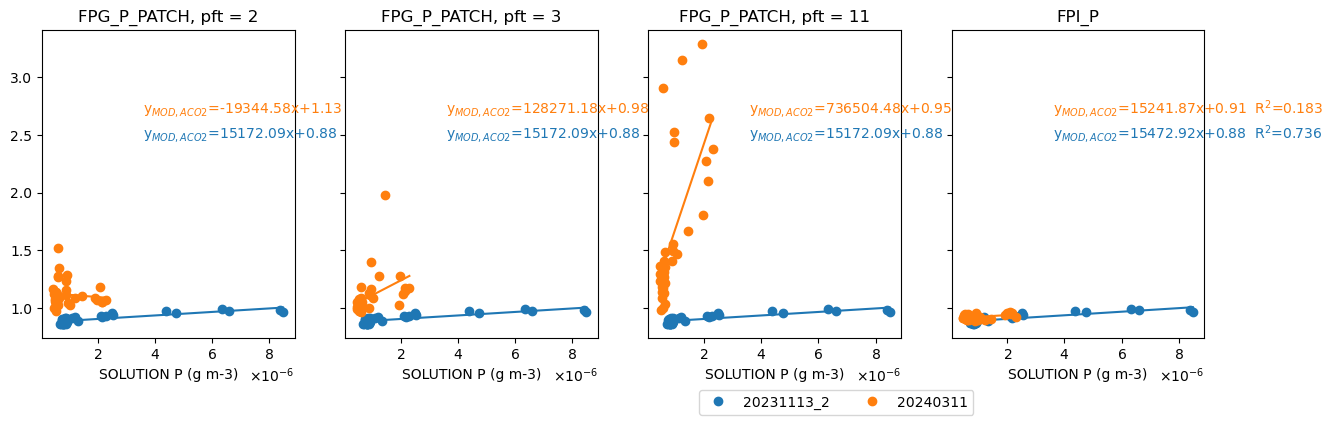

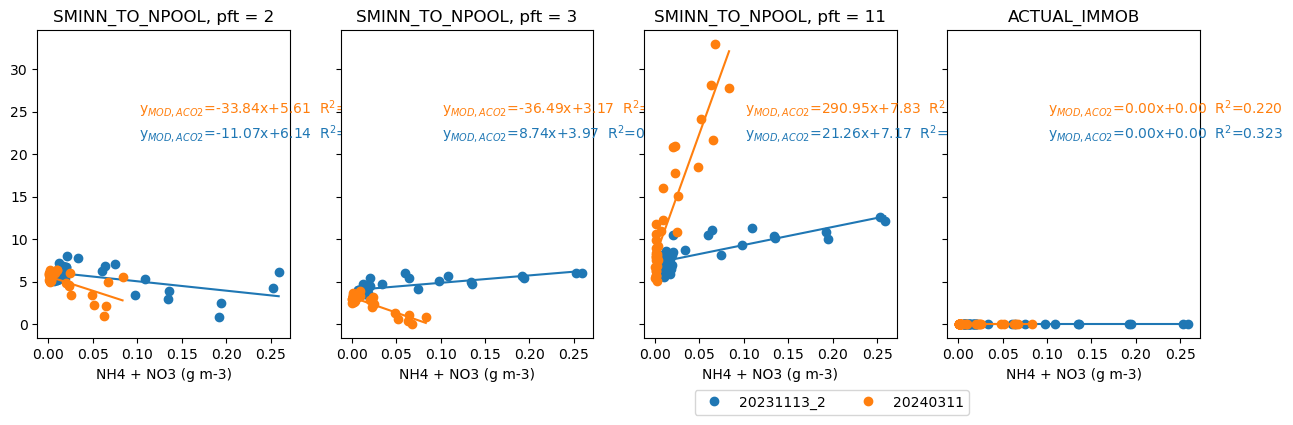

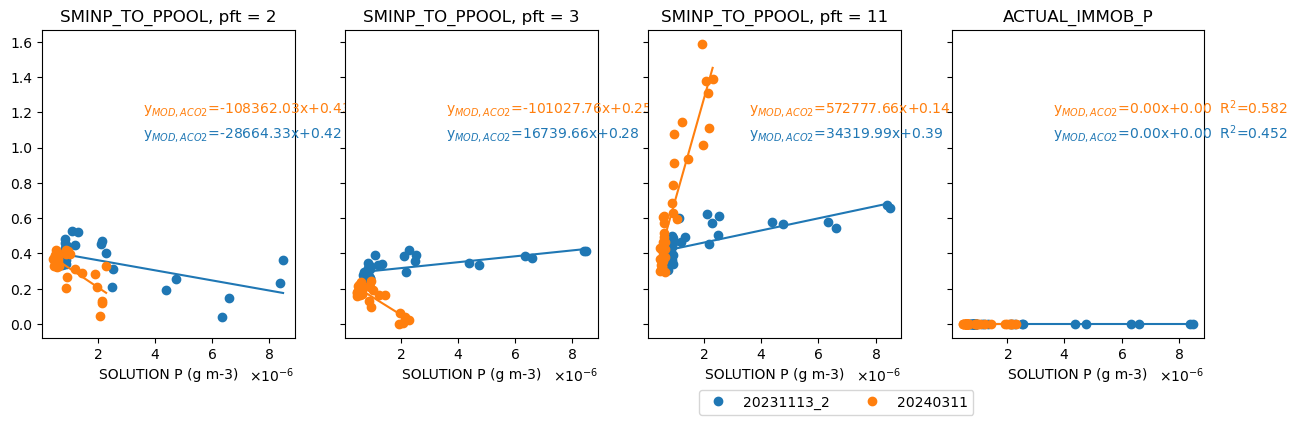

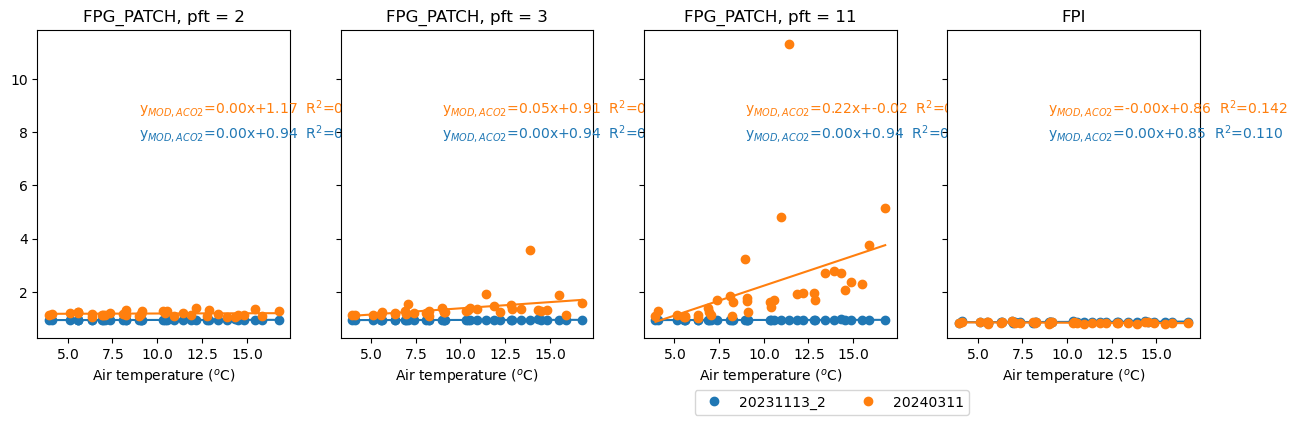

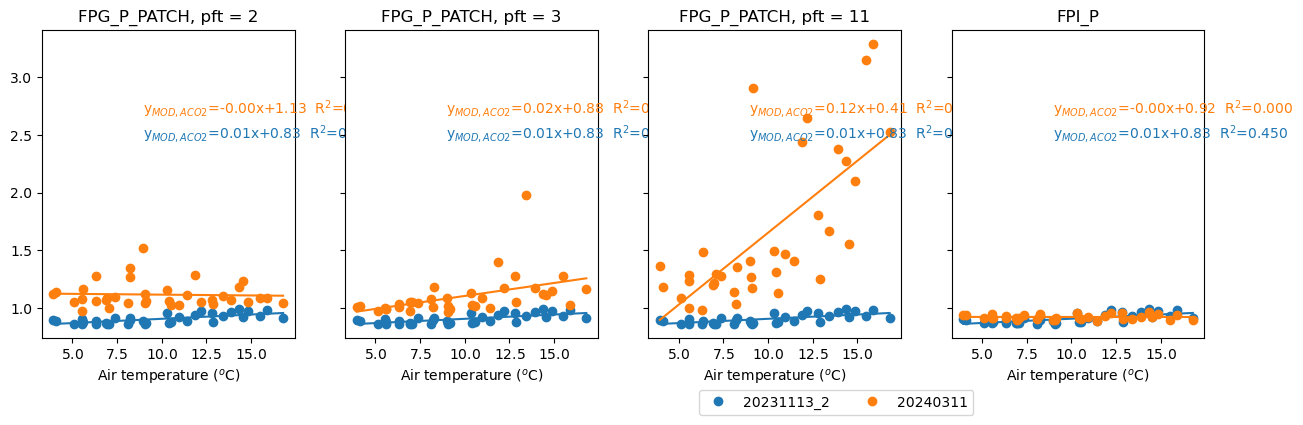

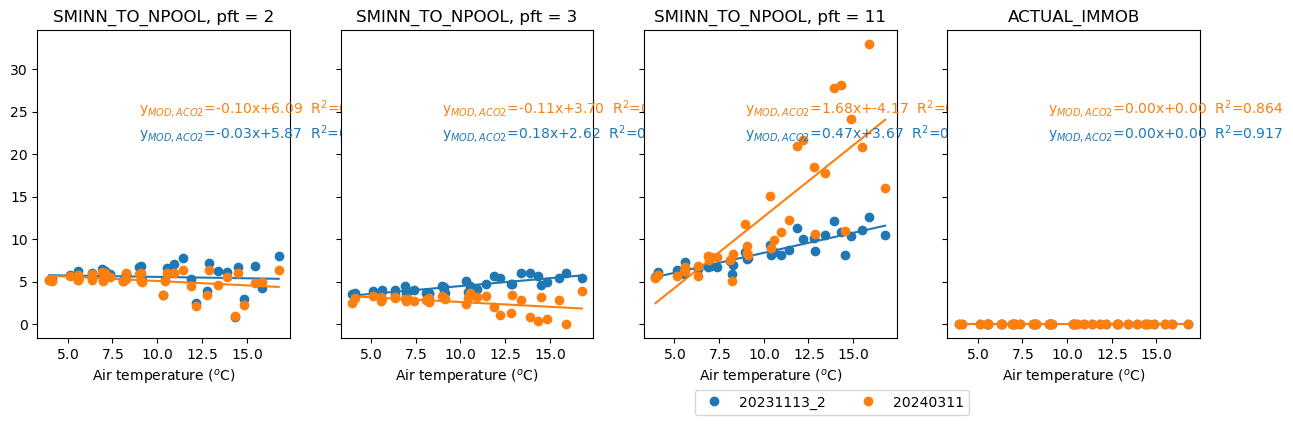

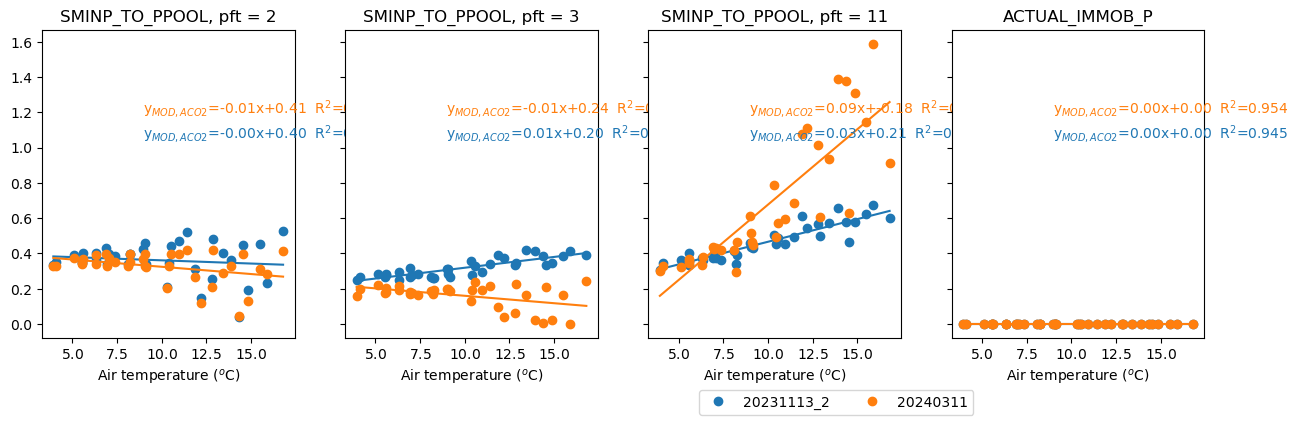

In [6]:
clist = ['#1f77b4', '#ff7f0e', '#2ca02c']

for xvar, xlabel in zip(['SMIN', 'TBOT'], ['content (g m-3)', 'Air temperature ($^o$C)']):

    for term1, term2 in zip(
        ['FPG_PATCH', 'FPG_P_PATCH', 'SMINN_TO_NPOOL', 'SMINP_TO_PPOOL'],
        ['FPI', 'FPI_P', 'ACTUAL_IMMOB', 'ACTUAL_IMMOB_P']
    ):
        fig, axes = plt.subplots(1, 4, figsize = (15, 4), sharex = True, sharey = True)

        # vegetation
        for i, pft in enumerate([2, 3, 11]):
            ax = axes.flat[i]
            for j, prefix in enumerate(prefix_list):
                temp_data = data_collection[prefix]

                if xvar == 'TBOT':
                    x = temp_data[('TBOT','0')]
                else:
                    if '_P' in term2: # ("_PATCH" is "_P")
                        x = temp_data[('SOLUTIONP_30','0')]
                    else:
                        x = temp_data[('SMINN_30','0')]

                if term1 == 'FPG_PATCH' and not 'FPG_PATCH' in temp_data.columns:
                    y = temp_data[('FPG', '0')]
                elif term1 == 'FPG_P_PATCH' and not 'FPG_P_PATCH' in temp_data.columns:
                    y = temp_data[('FPG_P', '0')]
                else:
                    if not term1 in ['SMINN_TO_NPOOL','SMINP_TO_PPOOL',
                                     'ACTUAL_IMMOB', 'ACTUAL_IMMOB_P']:
                        y = temp_data[(term1, str(pft))]
                    else:
                        y = temp_data[(term1, str(pft))] * 365 * 86400

                ax.plot(x, y, 'o', label = prefix)
                xnew, ynew, slope, intercept, r2 = fit_line(x, y)
                ax.plot(xnew, ynew, ls='-', color=clist[j], markerfacecolor='none')
                ax.text(0.4, 0.65 + j * 0.08, "y$_{MOD,ACO2}$=" + f"{slope:.2f}x+{intercept:.2f}  "
                        + "R$^2$=" + f"{r2:.3f}",color=clist[j], transform=ax.transAxes)
            ax.set_title(f'{term1}, pft = {pft}')
            if xvar == 'TBOT':
                ax.set_xlabel('Air temperature ($^o$C)')
            else:
                if '_P' in term2:
                    ax.set_xlabel('SOLUTION P (g m-3)')
                else:
                    ax.set_xlabel(f'NH4 + NO3 (g m-3)')

        # microbe
        ax = axes.flat[-1]
        for j, prefix in enumerate(prefix_list):
            temp_data = data_collection[prefix]
            if xvar == 'TBOT':
                x = temp_data[('TBOT','0')]
            else:
                if '_P' in term2:
                    x = temp_data[('SOLUTIONP_30','0')]
                else:
                    x = temp_data[('SMINN_30','0')]
            y = temp_data[(term2, '0')]

            ax.plot(x, y, 'o', label = prefix)
            xnew, ynew, slope, intercept, r2 = fit_line(x, y)
            ax.plot(xnew, ynew, ls='-', color=clist[j], markerfacecolor='none')
            ax.text(0.4, 0.65 + j * 0.08, "y$_{MOD,ACO2}$=" + f"{slope:.2f}x+{intercept:.2f}  "
                    + "R$^2$=" + f"{r2:.3f}",color=clist[j], transform=ax.transAxes)
        ax.set_title(f'{term2}')
        if xvar == 'TBOT':
            ax.set_xlabel('Air temperature ($^o$C)')
        else:
            if '_P' in term2:
                ax.set_xlabel('SOLUTION P (g m-3)')
            else:
                ax.set_xlabel(f'NH4 + NO3 (g m-3)')
            # ax.set_xscale('log')
        use_scientific_notation_for_xaxis()

        ax.legend(loc = [-1, -0.25], ncol = 3)

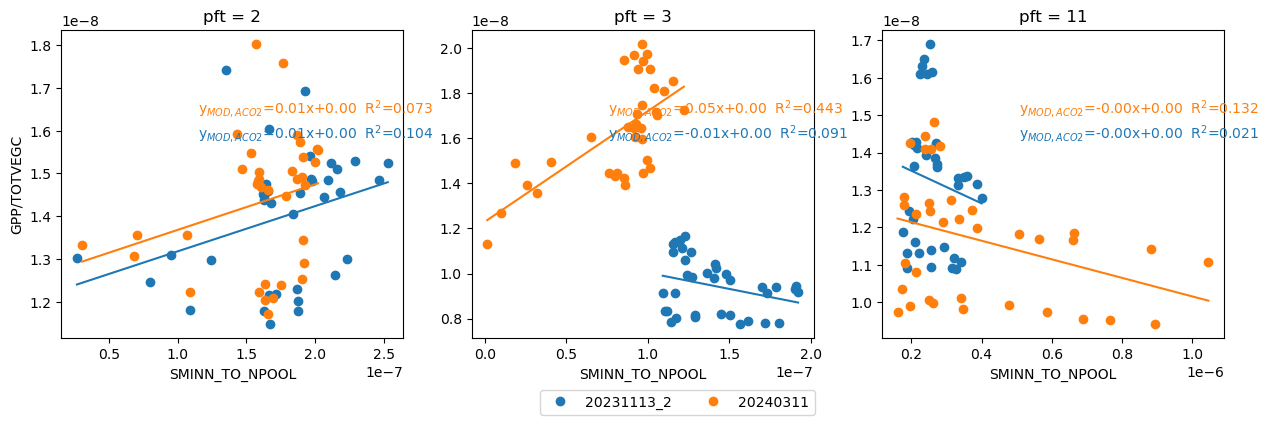

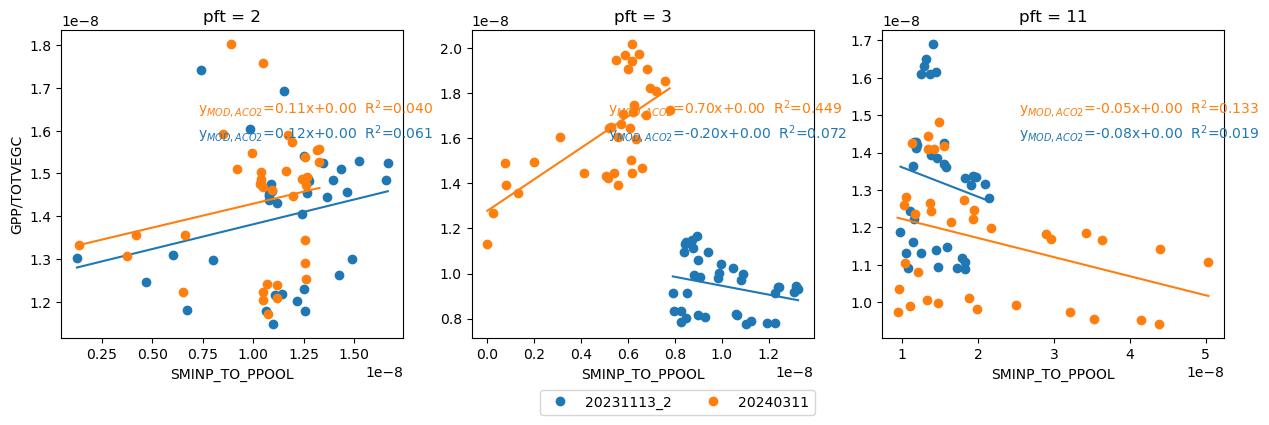

In [7]:
clist = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Check nutrient saturation for plants - Yes
for xterm in ['SMINN_TO_NPOOL', 'SMINP_TO_PPOOL']:
    fig, axes = plt.subplots(1, 3, figsize = (15, 4)) # , sharex = True, sharey = True)
    for i, pft in enumerate([2, 3, 11]):
        ax = axes.flat[i]
        for j, prefix in enumerate(prefix_list):
            temp_data = data_collection[prefix]

            x = temp_data[(xterm,str(pft))]
            y = temp_data[('GPP',str(pft))] / temp_data[('TOTVEGC',str(pft))] 
            ax.plot(x, y, 'o', label = prefix)

            xnew, ynew, slope, intercept, r2 = fit_line(x, y)
            ax.plot(xnew, ynew, ls='-', color=clist[j], markerfacecolor='none')
            ax.text(0.4, 0.65 + j * 0.08, "y$_{MOD,ACO2}$=" + f"{slope:.2f}x+{intercept:.2f}  "
                    + "R$^2$=" + f"{r2:.3f}",color=clist[j], transform=ax.transAxes)
        ax.set_title(f'pft = {pft}')
        ax.set_xlabel(xterm)
        if i == 0:
            ax.set_ylabel('GPP/TOTVEGC')
    ax.legend(loc = [-1, -0.25], ncol = 3)

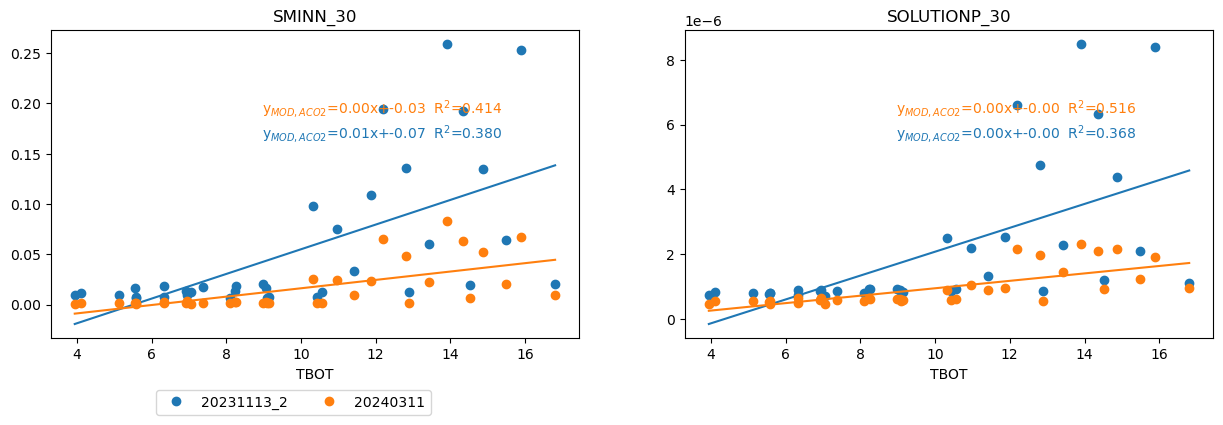

In [8]:
clist = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Check nutrient saturation for microbes - Yes
fig, axes = plt.subplots(1, 2, figsize = (15, 4)) # , sharex = True, sharey = True)
xterm = 'TBOT'
for i, yterm in enumerate(['SMINN_30', 'SOLUTIONP_30']):
    ax = axes.flat[i]
    for j, prefix in enumerate(prefix_list):
        temp_data = data_collection[prefix]

        x = temp_data[('TBOT','0')]
        y = temp_data[(yterm,'0')]
        ax.plot(x, y, 'o', label = prefix)

        xnew, ynew, slope, intercept, r2 = fit_line(x, y)
        ax.plot(xnew, ynew, ls='-', color=clist[j], markerfacecolor='none')
        ax.text(0.4, 0.65 + j * 0.08, "y$_{MOD,ACO2}$=" + f"{slope:.2f}x+{intercept:.2f}  "
                + "R$^2$=" + f"{r2:.3f}",color=clist[j], transform=ax.transAxes)
    ax.set_xlabel(xterm)
    ax.set_title(yterm)
ax.legend(loc = [-1, -0.25], ncol = 3)

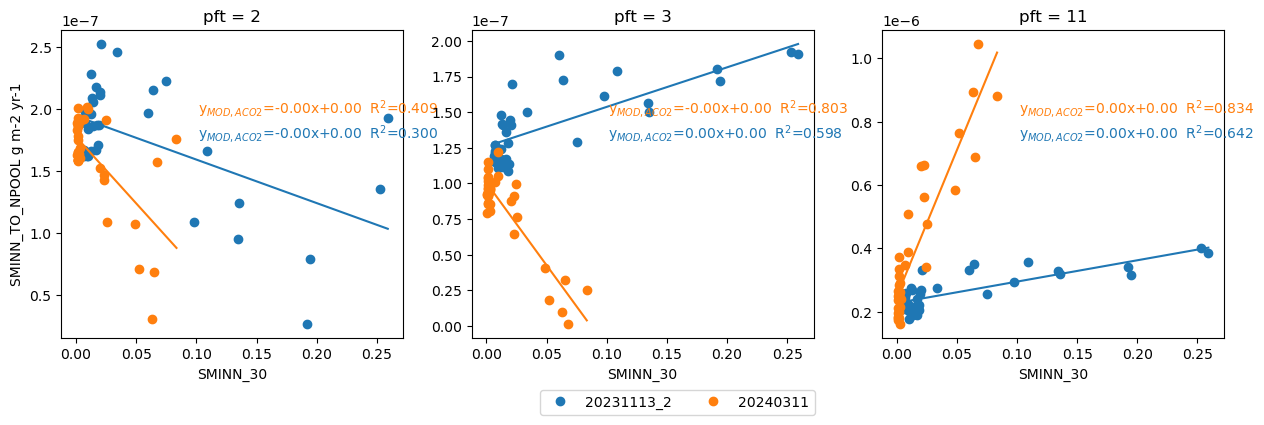

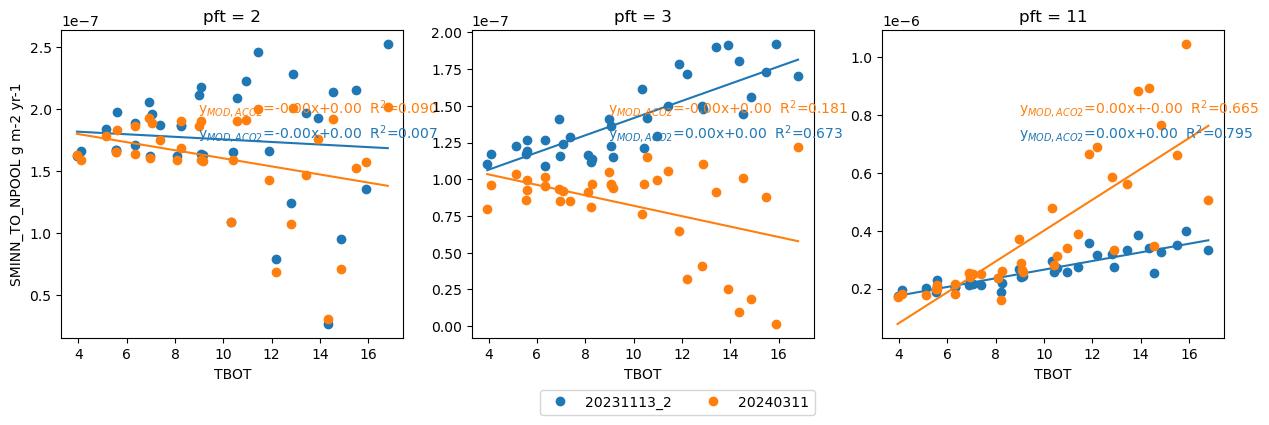

In [14]:
clist = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Plot the relationship between nutrient uptake and nutrient solution
for yterm, xterm in zip(['SMINN_TO_NPOOL', 'SMINN_TO_NPOOL'], ['SMINN_30','TBOT']):
    fig, axes = plt.subplots(1, 3, figsize = (15, 4)) # , sharex = True, sharey = True)
    for i, pft in enumerate([2, 3, 11]):
        ax = axes.flat[i]
        for j, prefix in enumerate(prefix_list):
            temp_data = data_collection[prefix]

            x = temp_data[(xterm,'0')]
            y = temp_data[(yterm,str(pft))]
            ax.plot(x, y, 'o', label = prefix)

            xnew, ynew, slope, intercept, r2 = fit_line(x, y)
            ax.plot(xnew, ynew, ls='-', color=clist[j], markerfacecolor='none')
            ax.text(0.4, 0.65 + j * 0.08, "y$_{MOD,ACO2}$=" + f"{slope:.2f}x+{intercept:.2f}  "
                    + "R$^2$=" + f"{r2:.3f}",color=clist[j], transform=ax.transAxes)
        ax.set_title(f'pft = {pft}')
        ax.set_xlabel(f'{xterm}')
        if i == 0:
            ax.set_ylabel(f'{yterm} g m-2 yr-1')
    ax.legend(loc = [-1, -0.25], ncol = 3)

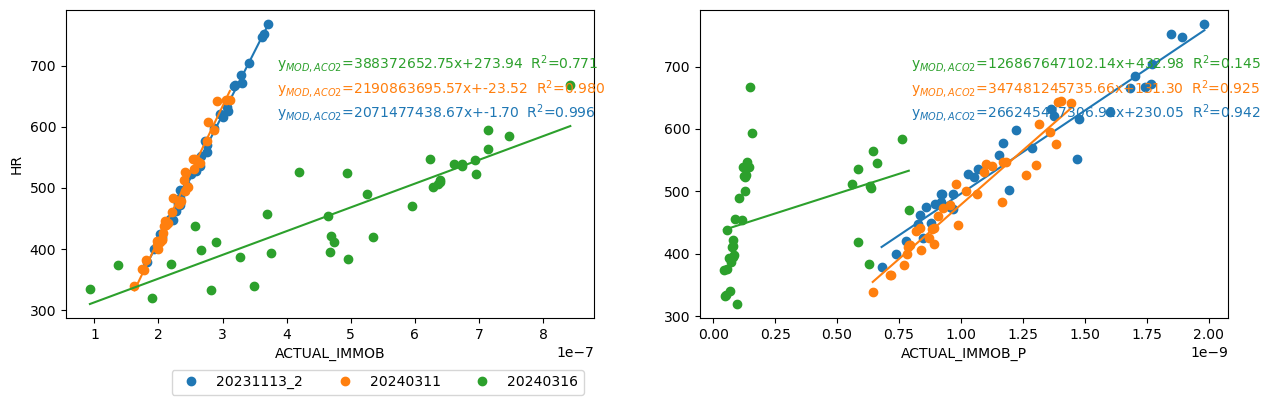

In [3]:
clist = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Check the relationship between nutrients level and temperature
fig, axes = plt.subplots(1, 2, figsize = (15, 4)) # , sharex = True, sharey = True)
for i, xterm in enumerate(['ACTUAL_IMMOB', 'ACTUAL_IMMOB_P']):
    ax = axes.flat[i]
    for j, prefix in enumerate(prefix_list):
        temp_data = data_collection[prefix]

        x = temp_data[(xterm,'0')]
        y = temp_data[('HR','0')] * 365 * 86400
        ax.plot(x, y, 'o', label = prefix)

        xnew, ynew, slope, intercept, r2 = fit_line(x, y)
        ax.plot(xnew, ynew, ls='-', color=clist[j], markerfacecolor='none')
        ax.text(0.4, 0.65 + j * 0.08, "y$_{MOD,ACO2}$=" + f"{slope:.2f}x+{intercept:.2f}  "
                + "R$^2$=" + f"{r2:.3f}",color=clist[j], transform=ax.transAxes)
    ax.set_xlabel(xterm)
    if i == 0:
        ax.set_ylabel('HR')
ax.legend(loc = [-1, -0.25], ncol = 3)

## Nutrient uptake and CNPOOL size

The seasonality in the NPOOL:CPOOL ratio is not very strong. So, I can do away with annual averages and look at the temperature response.

In [10]:
data_collection = {}
for prefix in prefix_list:
    temp_data = pd.read_csv(os.path.join(outdir, prefix, 'analysis_ts.csv'),
                                          header = [0, 1, 2, 3], index_col = 0, parse_dates=True)
    # average hummock and hollow; resample to annual
    temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
        ).apply(lambda df: df.iloc[:,0] * 0.64 + df.iloc[:,1] * 0.36)
    temp_data.columns = temp_data.columns.reorder_levels(['variable', 'pft', 'plot'])
    # focus on ambient plots only
    filt = [chamber_levels_complete[f'{int(c):02d}'][1] == 0 \
            for c in temp_data.columns.get_level_values(2)]
    temp_data = temp_data.loc[:, filt]
    data_collection[prefix] = temp_data.groupby(temp_data.index.year
        ).mean().sort_index(axis = 1).stack()

/tmp/ipykernel_1344867/2204224311.py:6: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
/tmp/ipykernel_1344867/2204224311.py:6: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1


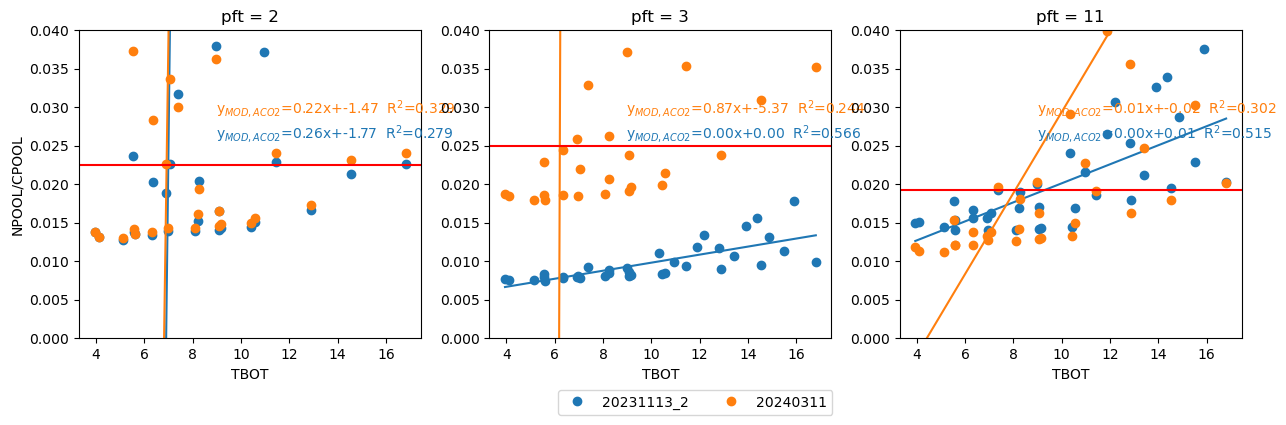

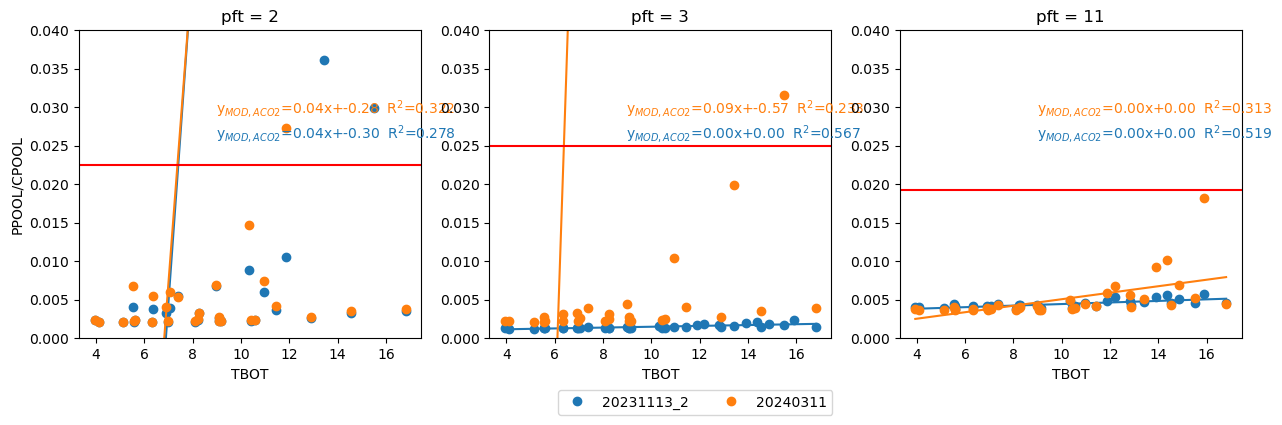

In [11]:
clist = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Check the NPOOL/CPOOL & PPOOL/CPOOL for the plants
for yterm in ['NPOOL', 'PPOOL']:
    fig, axes = plt.subplots(1, 3, figsize = (15, 4)) # , sharex = True, sharey = True)
    for i, pft in enumerate([2, 3, 11]):
        ax = axes.flat[i]
        for j, prefix in enumerate(prefix_list):
            temp_data = data_collection[prefix]

            x = temp_data[('TBOT', '0')]
            y = temp_data[(yterm,str(pft))] / temp_data[('CPOOL',str(pft))] 
            ax.plot(x, y, 'o', label = prefix)

            xnew, ynew, slope, intercept, r2 = fit_line(x, y)
            ax.plot(xnew, ynew, ls='-', color=clist[j], markerfacecolor='none')
            ax.text(0.4, 0.65 + j * 0.08, "y$_{MOD,ACO2}$=" + f"{slope:.2f}x+{intercept:.2f}  "
                    + "R$^2$=" + f"{r2:.3f}",color=clist[j], transform=ax.transAxes)
        ax.set_title(f'pft = {pft}')
        ax.set_xlabel('TBOT')
        if i == 0:
            ax.set_ylabel(f'{yterm}/CPOOL')
        
        ax.set_ylim([0, 0.04])
    
        # allometry line
        if pft == 2:
            ax.axhline(0.0225, color='r')
        elif pft == 3:
            ax.axhline(0.0249, color='r')
        elif pft == 11:
            ax.axhline(0.0192, color='r')

    ax.legend(loc = [-1, -0.25], ncol = 3)

In [1]:
# Fraction of fungi uptake, separately for hummock and hollow,
# for the simulations with competition routines.

clist = ['#ff7f0e', '#2ca02c'] # '#1f77b4', 

fig, axes = plt.subplots(1, 3, figsize = (15, 4), sharex = True, sharey = True)
for i, pft in enumerate([2, 3, 11]):
    ax = axes.flat[i]
    for j, prefix in enumerate(prefix_list):
        temp_data = data_collection[prefix]

        x = temp_data[('TBOT', '0')]
        y = temp_data[(yterm,str(pft))] / temp_data[('CPOOL',str(pft))]

        n_absorb = hr2['PLANT_NFUNGI_PATCH'][:, pft].resample(time='1Y').mean()
        n_demand = hr2['PLANT_NABSORB'][:, pft].resample(time='1Y').mean()

        y = np.exp(- y / allometry[pft])

        ax.plot(x, y, 'o', label = prefix)

        xnew, ynew, slope, intercept, r2 = fit_line(x, y)
        ax.plot(xnew, ynew, ls='-', color=clist[j], markerfacecolor='none')
        ax.text(0.4, 0.65 + j * 0.08, "y$_{MOD,ACO2}$=" + f"{slope:.2f}x+{intercept:.2f}  "
                + "R$^2$=" + f"{r2:.3f}",color=clist[j], transform=ax.transAxes)
    ax.set_title(f'pft = {pft}')
    ax.set_xlabel('TBOT')
    if i == 0:
        ax.set_ylabel(f'NSCARCITY')

ax.legend(loc = [-1, -0.25], ncol = 3)

NameError: name 'plt' is not defined